In [3]:
import torch
import pandas as pd

#Load directly from GitHub 
url_train = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
url_test = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"

train_df = pd.read_csv(url_train)
test_df = pd.read_csv(url_test)

print(f"PyTorch version: {torch.__version__}")
print(f"Training examples: {len(train_df)}")
print(f"Test examples: {len(test_df)}")
print(f"Number of intents: {train_df['category'].nunique()}")
print(train_df.head())

PyTorch version: 2.12.1+cpu
Training examples: 10003
Test examples: 3080
Number of intents: 77
                                                text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival


In [5]:
#Look at the data
print("=== Sample sentences ===")
print(train_df[['text', 'category']].head(10).to_string())

print("\n=== Intent categories (first 20) ===")
print(train_df['category'].unique()[:20])

print("\n=== How many examples per intent? ===")
print(train_df['category'].value_counts().value_counts().head(10))


=== Sample sentences ===
                                                           text      category
0                                I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived after 2 weeks?  card_arrival
2    I have been waiting over a week. Is the card still coming?  card_arrival
3   Can I track my card while it is in the process of delivery?  card_arrival
4        How do I know if I will get my card, or if it is lost?  card_arrival
5                             When did you send me my new card?  card_arrival
6                  Do you have info about the card on delivery?  card_arrival
7        What do I do if I still have not received my new card?  card_arrival
8                  Does the package with my card have tracking?  card_arrival
9                     I ordered my card but it still isn't here  card_arrival

=== Intent categories (first 20) ===
<ArrowStringArray>
[                    'card_arrival',                     'ca

In [6]:
from sklearn.preprocessing import LabelEncoder

# Convert text intent labels to numbers
le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['category'])
test_df['label'] = le.transform(test_df['category'])

print(f"Label example: 'activate_my_card' → {le.transform(['activate_my_card'])[0]}")
print(f"Total Clases: {len(le.classes_)}")
print(f"\nFirst 10 classes: {le.classes_[:10]}")

Label example: 'activate_my_card' → 1
Total Clases: 77

First 10 classes: ['Refund_not_showing_up' 'activate_my_card' 'age_limit'
 'apple_pay_or_google_pay' 'atm_support' 'automatic_top_up'
 'balance_not_updated_after_bank_transfer'
 'balance_not_updated_after_cheque_or_cash_deposit'
 'beneficiary_not_allowed' 'cancel_transfer']


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertModel

# --- 1. Tokenizer -----------------
# DistilBert is smaller, faster version of BERT - Perfect for beginners
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# --- 2. Dataset class -------------
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }
    
# --- 3. Create datasets --------------
train_dataset = IntentDataset(
    train_df['text'].tolist(),
    train_df['label'].tolist(),
    tokenizer
)    

test_dataset = IntentDataset(
    test_df['text'].tolist(),
    test_df['label'].tolist(),
    tokenizer
)

# --- 4. Create dataloaders ----------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print("Dataset Ready!")


Training batches: 313
Test batches: 97
Dataset Ready!


In [15]:
# --- Intent Classifier Model -------
class IntentClassifier(nn.Module):
    def __init__(self, num_classes=77):
        super(IntentClassifier, self).__init__()
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids = input_ids,
            attention_mask = attention_mask
        )
        #Take the [CLS] token outout - it summarizes the whole sentence
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        return self.classifier(cls_output)
    
# --- Setup ----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = IntentClassifier(num_classes=77)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

print("Model ready!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



Using device: cpu


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready!
Total parameters: 66,422,093


In [16]:
# --- Training Loop ------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        #Progress update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx + 1}/{len(loader)}"
                  f"- Loss: {loss.item():.4f} "
                  f"- Acc: {correct/total*100:.1f}% ")
        
    return total_loss / len(loader), correct / total * 100

# --- Evaluation Loop --------------------
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total * 100

# --- Run Training ------------------------
print("Starting training...")
print("=" * 50)

NUM_EPOCHS = 3

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_epoch(
        model, train_loader, optimizer, criterion, device
    )
    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\n Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
    print(f" Test Loss: {test_loss:.4f} | Test Acc: {test_acc:1f}%")

print("\n" + "=" * 50)
print("Training Complete!")

Starting training...

Epoch 1/3
----------------------------------------
  Batch 50/313- Loss: 4.1820 - Acc: 2.6% 
  Batch 100/313- Loss: 3.4138 - Acc: 11.3% 
  Batch 150/313- Loss: 2.7645 - Acc: 23.2% 
  Batch 200/313- Loss: 2.1597 - Acc: 31.9% 
  Batch 250/313- Loss: 1.8298 - Acc: 38.9% 
  Batch 300/313- Loss: 1.4948 - Acc: 44.8% 

 Train Loss: 2.7329 | Train Acc: 46.1%
 Test Loss: 1.2170 | Test Acc: 77.305195%

Epoch 2/3
----------------------------------------
  Batch 50/313- Loss: 0.8998 - Acc: 79.6% 
  Batch 100/313- Loss: 1.2374 - Acc: 81.1% 
  Batch 150/313- Loss: 0.8999 - Acc: 82.8% 
  Batch 200/313- Loss: 0.7351 - Acc: 83.8% 
  Batch 250/313- Loss: 0.7580 - Acc: 84.5% 
  Batch 300/313- Loss: 0.8245 - Acc: 84.9% 

 Train Loss: 0.8681 | Train Acc: 85.1%
 Test Loss: 0.5519 | Test Acc: 89.318182%

Epoch 3/3
----------------------------------------
  Batch 50/313- Loss: 0.4836 - Acc: 91.0% 
  Batch 100/313- Loss: 0.4544 - Acc: 91.1% 
  Batch 150/313- Loss: 0.5552 - Acc: 91.3% 
  B

In [17]:
import torch

torch.save(model.state_dict(), '../model.pth')
print("Model saved to model.pth")

Model saved to model.pth


In [18]:
import json

#Re-run evaluation to get final numbers (or reuse test_loss, test_acc if still in memory)
final_test_loss, final_test_acc = evaluate(model, test_loader, criterion, device)

results = {
    "train_accuracy": train_acc,
    "test_accuracy": final_test_acc,
    "test_loss": final_test_loss,
    "num_intents": 77,
    "training_examples": len(train_df),
    "test_examples": len(test_df)
}

with open('../results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to results.json")
print(results)

Results saved to results.json
{'train_accuracy': 91.91242627211837, 'test_accuracy': 90.74675324675324, 'test_loss': 0.3963451589428887, 'num_intents': 77, 'training_examples': 10003, 'test_examples': 3080}


=== Top 10 Most Confused Intent Pairs ===

  True: why_verify_identity                 → Predicted: verify_my_identity                  (11 times)
  True: wrong_exchange_rate_for_cash_withdrawal → Predicted: cash_withdrawal_charge              (6 times)
  True: balance_not_updated_after_bank_transfer → Predicted: transfer_timing                     (5 times)
  True: card_delivery_estimate              → Predicted: card_arrival                        (5 times)
  True: get_disposable_virtual_card         → Predicted: getting_virtual_card                (5 times)
  True: beneficiary_not_allowed             → Predicted: failed_transfer                     (4 times)
  True: card_about_to_expire                → Predicted: order_physical_card                 (4 times)
  True: card_payment_not_recognised         → Predicted: compromised_card                    (4 times)
  True: declined_transfer                   → Predicted: declined_card_payment               (4 times)
  True: pending_trans

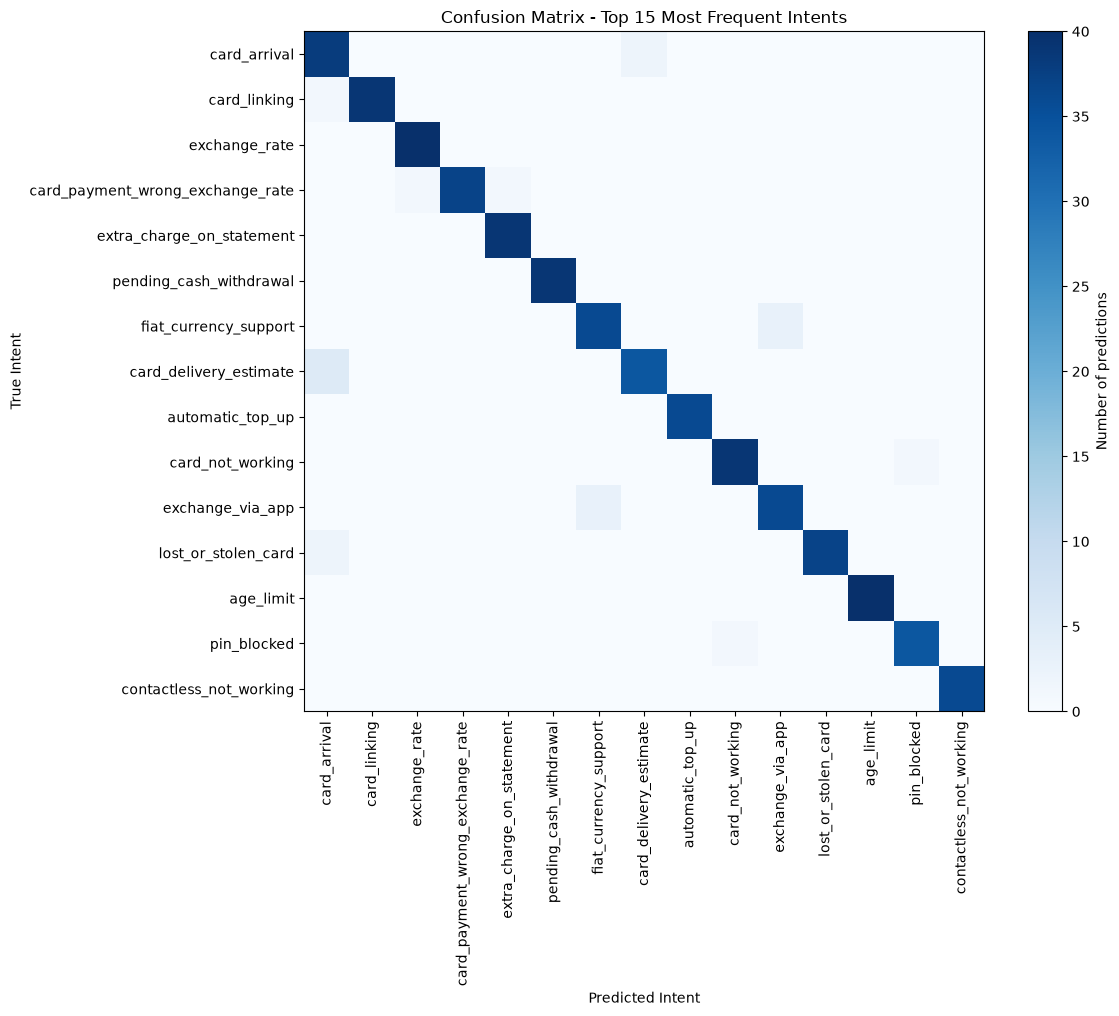


Confusion matrix saved to confusion_matrix.png
Classification report saved to classification_report.json


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. Collect all predictions on the test set ---------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        predicted = outputs.argmax(dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # --- 2. Find the most-confused intent pairs -------------
    cm = confusion_matrix(all_labels, all_preds)
    intent_names = le.classes_

    # Zero out the diagonal so we only see mistakes, not correct predictions
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)

    # Get the top 10 most common confusions
    confused_pairs = []
    for i in range(len(intent_names)):
        for j in range(len(intent_names)):
            if cm_errors[i, j] > 0:
                confused_pairs.append((intent_names[i], intent_names[j], cm_errors[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("=== Top 10 Most Confused Intent Pairs ===\n")
for true_intent, pred_intent, count in confused_pairs[:10]:
    print(f"  True: {true_intent:<35} → Predicted: {pred_intent:<35} ({count} times)")

# --- 3. Plot a focused confusion matrix (top 15 most frequent intents) --------
top_15_idx = pd.Series(all_labels).value_counts().head(15).index.tolist()
top_15_names = [intent_names[i] for i in top_15_idx]

cm_subset = confusion_matrix(
    all_labels, all_preds,
    labels=top_15_idx
)

plt.figure(figsize=(12, 10))
plt.imshow(cm_subset, cmap='Blues')
plt.colorbar(label='Number of predictions')
plt.xticks(range(15), top_15_names, rotation=90)
plt.yticks(range(15), top_15_names)
plt.xlabel('Predicted Intent')
plt.ylabel('True Intent')
plt.title('Confusion Matrix - Top 15 Most Frequent Intents')
plt.tight_layout()
plt.savefig('../confusion_matrix.png', dpi=150)
plt.show()

print("\nConfusion matrix saved to confusion_matrix.png")

# --- 4. Full classification report ---------------
report = classification_report(
    all_labels, all_preds,
    target_names = intent_names,
    output_dict = True
)

with open('../classification_report.json', "w") as f:
    json.dump(report, f, indent=2)

print("Classification report saved to classification_report.json")